# break into each year and composites

In [1]:
from global_snowmelt_runoff_onset.config import Config
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-05-01 05:50 UTC (224.8 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [1]:
# global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
# global_ds

In [ ]:
config.azure_blob_fs.ls('snowmelt/snowmelt_runoff_onset/global_v9.zarr')

In [ ]:
# first download the complete zarr dataset
#config.azure_blob_fs.download('snowmelt/snowmelt_runoff_onset/global_v9.zarr',lpath="~/repos/global_snowmelt_runoff_onset/dataset/global_v9.zarr",recursive=True)

In [4]:
from __future__ import annotations
import shutil
import subprocess
from pathlib import Path

import xarray as xr
import rioxarray  # noqa: F401  (registers .rio accessor)

SRC = Path.home() / "repos/global_snowmelt_runoff_onset/dataset/global_snowmelt_runoff_onset.zarr"
OUT_DIR = Path.home() / "repos/global_snowmelt_runoff_onset/dataset/redistribution"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ANNUAL_VARS = ["runoff_onset", "temporal_resolution"]
COMPOSITE_VARS = ["runoff_onset_median", "runoff_onset_mad", "temporal_resolution_median"]
COORD_NAMES = ["latitude", "longitude"]

# encoding keys to carry over from the source store
_ENC_KEYS = ("chunks", "compressor", "filters", "_FillValue",
             "dtype", "scale_factor", "add_offset")

def annual_path(wy: int) -> Path:
    return OUT_DIR / f"global_snowmelt_runoff_onset_WY{wy}.zarr"

COMPOSITES_PATH = OUT_DIR / "global_snowmelt_runoff_onset_composites.zarr"

In [5]:
def copy_encoding(src_ds: xr.Dataset, names: list[str]) -> dict:
    """Carry over the on-disk encoding for the given variables/coords."""
    enc = {}
    for name in names:
        if name not in src_ds.variables:
            continue
        src_enc = src_ds[name].encoding
        enc[name] = {k: src_enc[k] for k in _ENC_KEYS if k in src_enc}
    return enc

def write_sparse_zarr(ds: xr.Dataset, encoding: dict, zarr_out: Path) -> None:
    """Write a Zarr store preserving sparse chunk storage."""
    if zarr_out.exists():
        shutil.rmtree(zarr_out)
    for v in ds.data_vars:
        ds[v].attrs["grid_mapping"] = "spatial_ref"
    ds.to_zarr(
        zarr_out,
        mode="w",
        encoding=encoding,
        write_empty_chunks=False,   # preserves sparsity
        consolidated=True,
    )

def dir_size_gb(path: Path) -> float:
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e9

In [51]:
src_ds = xr.open_zarr(SRC, consolidated=True, decode_coords="all")
print("Water years:", list(src_ds.water_year.values))
print("Variables:  ", list(src_ds.data_vars))
print()
# Peek at the encoding we're about to replicate
for v in ANNUAL_VARS + COMPOSITE_VARS:
    enc = src_ds[v].encoding
    print(f"{v:30s} dtype={enc.get('dtype')}  chunks={enc.get('chunks')}  "
          f"scale={enc.get('scale_factor')}  fill={enc.get('_FillValue')}")
src_ds

Water years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables:   ['runoff_onset', 'runoff_onset_mad', 'runoff_onset_median', 'temporal_resolution', 'temporal_resolution_median']

runoff_onset                   dtype=int16  chunks=(1, 2048, 2048)  scale=None  fill=-9999
temporal_resolution            dtype=int16  chunks=(1, 2048, 2048)  scale=0.10000000149011612  fill=-9999
runoff_onset_median            dtype=int16  chunks=(2048, 2048)  scale=None  fill=-9999
runoff_onset_mad               dtype=int16  chunks=(2048, 2048)  scale=0.10000000149011612  fill=-9999
temporal_resolution_median     dtype=int16  chunks=(2048, 2048)  scale=0.10000000149011612  fill=-9999


<xarray.Dataset> Size: 14TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [63]:
rainier_ds = src_ds.rio.clip_box(
    minx=-122, miny=46.7, maxx=-121.5, maxy=47, crs="EPSG:4326"
)
rainier_ds

<xarray.Dataset> Size: 41MB
Dimensions:                     (latitude: 417, longitude: 696, water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 3kB 47.0 47.0 ... 46.7 46.7
  * longitude                   (longitude) float64 6kB -122.0 -122.0 ... -121.5
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
    spatial_ref                 int64 8B 0
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 12MB dask.array<chunksize=(1, 417, 696), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 2MB dask.array<chunksize=(417, 696), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 1MB dask.array<chunksize=(417, 696), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 23MB dask.array<chunksize=(1, 417, 696), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 2MB dask.array<chunksize=(417, 696), meta=np.ndarray>
Attributes:
    processed_tiles:  []

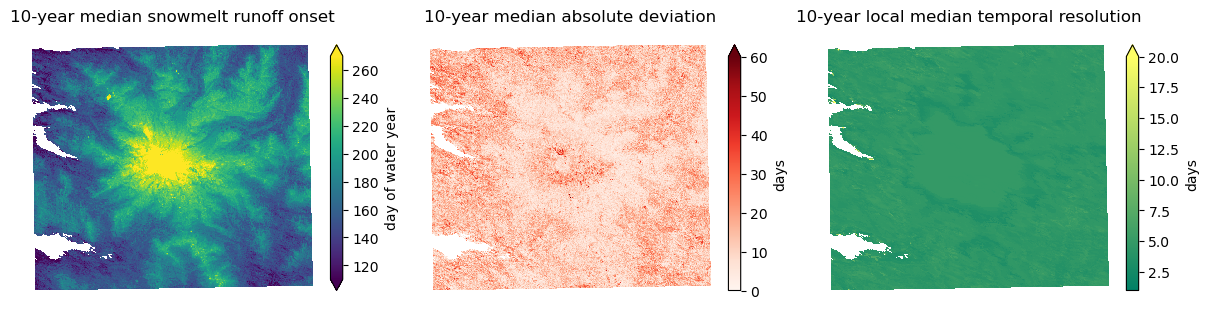

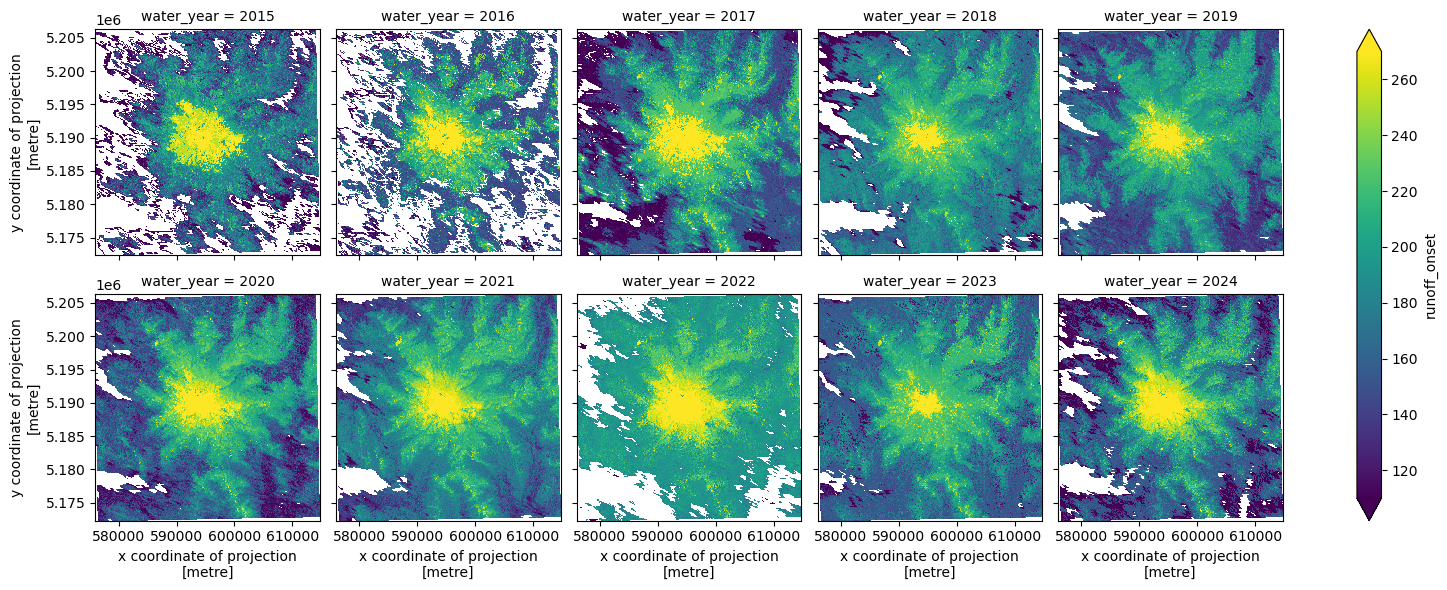

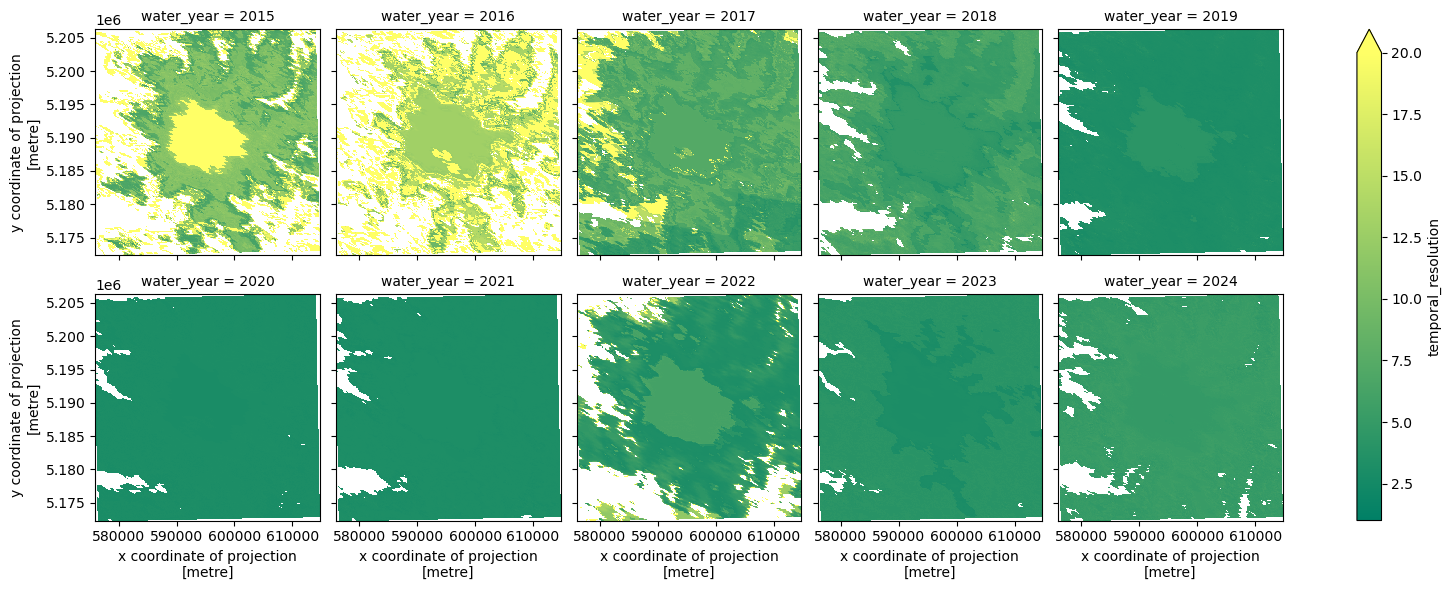

In [74]:
rainier_utm_ds = rainier_ds.rio.reproject("EPSG:32610")

# 4. Create a quick plot of the composite variables
f,axs = plt.subplots(figsize=(12, 3), ncols=3, nrows=1)
rainier_utm_ds["runoff_onset_median"].plot.imshow(ax=axs[0], cmap='viridis', vmin=110, vmax=270, cbar_kwargs={'label': 'day of water year'})
rainier_utm_ds["runoff_onset_mad"].plot.imshow(ax=axs[1], cmap='Reds', vmin=0, vmax=60, cbar_kwargs={'label': 'days'})
rainier_utm_ds["temporal_resolution_median"].plot.imshow(ax=axs[2], cmap='summer', vmin=1, vmax=20, cbar_kwargs={'label': 'days'})

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

axs[0].set_title("10-year median snowmelt runoff onset")
axs[1].set_title("10-year median absolute deviation")
axs[2].set_title("10-year local median temporal resolution")
f.tight_layout()


rainier_utm_ds["runoff_onset"].plot.imshow(col='water_year', col_wrap=5, cmap='viridis', vmin=110, vmax=270, subplot_kws={'aspect': 'equal'})
rainier_utm_ds["temporal_resolution"].plot.imshow(col='water_year', col_wrap=5, cmap='summer', vmin=1, vmax=20, subplot_kws={'aspect': 'equal'})

In [ ]:
# write annual files
# Skips any year whose zarr directory already exists (delete manually to rewrite).
all_years = [int(y) for y in src_ds.water_year.values]

for wy in all_years:
    zarr_out = annual_path(wy)
    if zarr_out.exists():
        print(f"[WY{wy}] {zarr_out.name} exists, skipping")
        continue

    ds_wy = src_ds[ANNUAL_VARS].sel(water_year=[wy])
    encoding = copy_encoding(src_ds, ANNUAL_VARS + COORD_NAMES)
    print(f"[WY{wy}] writing ...", flush=True)
    write_sparse_zarr(ds_wy, encoding, zarr_out)
    print(f"[WY{wy}] done ({dir_size_gb(zarr_out):.2f} GB)", flush=True)

[WY2015] global_snowmelt_runoff_onset_WY2015.zarr exists, skipping
[WY2016] writing ...
[WY2016] done (1.73 GB)
[WY2017] writing ...
[WY2017] done (6.55 GB)
[WY2018] writing ...
[WY2018] done (5.71 GB)
[WY2019] writing ...
[WY2019] done (5.84 GB)
[WY2020] writing ...
[WY2020] done (5.92 GB)
[WY2021] writing ...
[WY2021] done (6.00 GB)
[WY2022] writing ...
[WY2022] done (2.96 GB)
[WY2023] writing ...
[WY2023] done (3.26 GB)
[WY2024] writing ...
[WY2024] done (3.04 GB)


In [ ]:
# write composite file
ds_comp = src_ds[COMPOSITE_VARS]
encoding = copy_encoding(src_ds, COMPOSITE_VARS + COORD_NAMES)

print(f"Writing {COMPOSITES_PATH.name} ...")
write_sparse_zarr(ds_comp, encoding, COMPOSITES_PATH)
print(f"Done ({dir_size_gb(COMPOSITES_PATH):.2f} GB)")

Writing global_snowmelt_runoff_onset_composites.zarr ...
Done (17.41 GB)


In [ ]:
# to confirm seperate files can recreate original store, we recreate the original dataset by merging the annual subsets and composite back together
ds = xr.merge([
    xr.open_mfdataset(
        "../dataset/redistribution/global_snowmelt_runoff_onset_WY*.zarr",
        engine="zarr", consolidated=True, decode_coords="all",
        combine="nested", concat_dim="water_year",
    ),
    xr.open_zarr("../dataset/redistribution/global_snowmelt_runoff_onset_composites.zarr", consolidated=True, decode_coords="all"),
])
ds

<xarray.Dataset> Size: 14TB
Dimensions:                     (water_year: 10, latitude: 195970,
                                 longitude: 499998)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B 4326
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [ ]:
# now we can tar the zarr stores to turn them into files rather tahn directories (we need to do this to upload to zenodo, which doesn't support directories or zarr stores directly)
def tar_zarr(zarr_dir: Path, remove_zarr_after: bool = False) -> Path:
    tar_path = zarr_dir.parent / (zarr_dir.name + ".tar")
    print(f"  tarring {zarr_dir.name} -> {tar_path.name}", flush=True)
    subprocess.run(
        ["tar", "-cf", str(tar_path),
         "-C", str(zarr_dir.parent), zarr_dir.name],
        check=True,
    )
    if remove_zarr_after:
        shutil.rmtree(zarr_dir)
    return tar_path

all_zarrs = [annual_path(int(y)) for y in src_ds.water_year.values] + [COMPOSITES_PATH]

tars = []
for z in all_zarrs:
    if not z.exists():
        print(f"SKIPPING missing: {z.name}")
        continue
    tars.append(tar_zarr(z, remove_zarr_after=False))  # keep zarrs until you're sure

print("\n=== Summary ===")
total = 0.0
for t in tars:
    gb = t.stat().st_size / 1e9
    total += gb
    print(f"  {t.name:60s} {gb:6.2f} GB")
print(f"  {'TOTAL':60s} {total:6.2f} GB  ({len(tars)} files)")

  tarring global_snowmelt_runoff_onset_WY2015.zarr -> global_snowmelt_runoff_onset_WY2015.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2016.zarr -> global_snowmelt_runoff_onset_WY2016.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2017.zarr -> global_snowmelt_runoff_onset_WY2017.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2018.zarr -> global_snowmelt_runoff_onset_WY2018.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2019.zarr -> global_snowmelt_runoff_onset_WY2019.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2020.zarr -> global_snowmelt_runoff_onset_WY2020.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2021.zarr -> global_snowmelt_runoff_onset_WY2021.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2022.zarr -> global_snowmelt_runoff_onset_WY2022.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2023.zarr -> global_snowmelt_runoff_onset_WY2023.zarr.tar
  tarring global_snowmelt_runoff_onset_WY2024.zarr -> global_snowmelt_runoff_onset_WY2024.zarr.tar
  tarring 

In [ ]:
# Only run after confirming all .zarr.tar files are valid (try extracting one
# and opening it with xarray.open_zarr in a fresh kernel).
# for z in all_zarrs:
#     if z.exists():
#         print(f"Removing {z.name}")
#         shutil.rmtree(z)

In [ ]:
# now we have .tar files, we can build a reference json to the complete zarr tar so that we can open it remotely without downloading the whole tar (e.g. with kerchunk + fsspec reference filesystem)
import base64
import json
import tarfile
from pathlib import Path


def build_tar_reference(tar_path: Path, remote_url: str) -> dict:
    """
    Walk a .tar containing a single Zarr store, record byte offsets of each
    member, and emit a kerchunk-style references dict pointing into the remote tar.

    Tar member layout: [512B header][content padded to 512B multiple][next member...]
    member.offset_data is the byte offset of the content within the tar.
    """
    refs = {"version": 1, "refs": {}}

    with tarfile.open(tar_path, "r") as tf:
        # Figure out the top-level dir name inside the tar (e.g. "global_snowmelt_runoff_onset.zarr/")
        # so we can strip it and make ref paths relative to the store root.
        first = next(m for m in tf if m.isfile() or m.isdir())
        top = first.name.split("/", 1)[0]
        tf.fileobj.seek(0)
        tf = tarfile.open(tar_path, "r")  # reopen: we just consumed the iterator

        for member in tf:
            if not member.isfile():
                continue
            if not member.name.startswith(top + "/"):
                continue
            rel_path = member.name[len(top) + 1:]  # path inside the .zarr store

            # Inline small metadata + coord chunks so opens don't pay HTTP round-trips per read
            is_meta = rel_path.endswith((".zattrs", ".zarray", ".zgroup", ".zmetadata"))
            is_coord = rel_path.startswith(
                ("latitude/", "longitude/", "water_year/", "spatial_ref/")
            )
            if member.size < 1_000_000 and (is_meta or is_coord):
                tf.fileobj.seek(member.offset_data)
                data = tf.fileobj.read(member.size)
                refs["refs"][rel_path] = "base64:" + base64.b64encode(data).decode()
            else:
                # Remote reference: [url, offset, length]
                refs["refs"][rel_path] = [remote_url, member.offset_data, member.size]

    return refs

In [49]:
# --- build the single reference for the complete store ---
# NOTE: reserve the v1.1.0 DOI in Zenodo first so this URL is final.
RECORD_ID = 19618062
ZENODO_BASE = f"https://zenodo.org/records/{RECORD_ID}/files"  # <-- fill in after reserving DOI
TAR_NAME = "global_snowmelt_runoff_onset.zarr.tar"

tar_path = Path('../dataset/') / TAR_NAME
remote_url = f"{ZENODO_BASE}/{TAR_NAME}"

print(f"indexing {tar_path.name} ...", flush=True)
refs = build_tar_reference(tar_path, remote_url)

out_json = tar_path.with_suffix(".tar.refs.json")
with open(out_json, "w") as f:
    json.dump(refs, f)

print(f"-> {out_json.name}  ({len(refs['refs']):,} entries, "
      f"{out_json.stat().st_size/1e6:.1f} MB)")

indexing global_snowmelt_runoff_onset.zarr.tar ...
-> global_snowmelt_runoff_onset.zarr.tar.refs.json  (102,444 entries, 13.7 MB)


In [2]:
# # test reference json locally
# import fsspec, xarray as xr
# import rioxarray  # noqa

# # Point at the LOCAL tar to test the references without hitting the network
# local_refs = json.load(open(out_json))
# for k, v in local_refs["refs"].items():
#     if isinstance(v, list):
#         v[0] = f"file://{tar_path}"  # swap remote URL for local path

# mapper = fsspec.get_mapper("reference://", fo=local_refs, remote_protocol="file")
# ds = xr.open_zarr(mapper, consolidated=False, decode_coords="all")

# rainier_ds = ds.rio.clip_box(
#     minx=-121.95, miny=46.7, maxx=-121.45, maxy=46.95, crs="EPSG:4326"
# ).compute()
# rainier_ds

# access directly from cloud storage

In [ ]:
global_ds = xr.open_zarr("https://uwcryo.blob.core.windows.net/snowmelt/snowmelt_runoff_onset/global_v9.zarr", consolidated=True, decode_coords='all')
global_ds

In [ ]:
rainier_ds = global_ds.rio.clip_box(minx=-121.95, miny=46.7, maxx=-121.45, maxy=46.95, crs="EPSG:4326")
rainier_ds

In [ ]:
rainier_utm_ds = rainier_ds.rio.reproject("EPSG:32610")

# 4. Create a quick plot of the composite variables
f,axs = plt.subplots(figsize=(15, 5), ncols=3, nrows=1)
rainier_utm_ds["runoff_onset_median"].plot.imshow(ax=axs[0], cmap='viridis', vmin=110, vmax=270, cbar_kwargs={'label': 'day of water year'})
rainier_utm_ds["runoff_onset_mad"].plot.imshow(ax=axs[1], cmap='Reds', vmin=0, vmax=60, cbar_kwargs={'label': 'days'})
rainier_utm_ds["temporal_resolution_median"].plot.imshow(ax=axs[2], cmap='summer', vmin=1, vmax=20, cbar_kwargs={'label': 'days'})

for ax in axs:
    ax.axis('off')
    ax.set_aspect('equal')

axs[0].set_title("10-year median snowmelt runoff onset")
axs[1].set_title("10-year median absolute deviation")
axs[2].set_title("10-year local median temporal resolution")
f.tight_layout()


rainier_utm_ds["runoff_onset"].plot.imshow(col='water_year', cmap='viridis', vmin=110, vmax=270)
rainier_utm_ds["temporal_resolution"].plot.imshow(col='water_year', cmap='summer', vmin=1, vmax=20)

